In [1]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from src.models.heston import simulate_heston
from src.derivatives.european_call import black_scholes_call, black_scholes_delta
from src.strategies.neural_hedge import NeuralHedge
from src.portfolio import run_hedge_torch
from src.train import fit
from src.losses import MSEHedgingLoss, CVaRLoss, EntropicRiskLoss

In [3]:
SEED = 123
MODEL_SEED = 456

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

DTYPE = torch.float32

print("device:", device)

device: mps


In [4]:
# experiment params

S0 = 100.0
K = 100.0

r = 0.0
T = 1.0

v0 = 0.20**2
theta = 0.20**2

kappa = 2.0
xi = 0.40
rho = -0.70

transaction_cost_rate = 0.001

n_steps = 52


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 2048 # bigger for CVaR

n_epochs = 50

learning_rate = 1e-3

In [5]:
train_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123
)

val_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456
)

test_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789
)

print(train_sim_np.spot.shape)
print(train_sim_np.variance.shape)

assert np.all(train_sim_np.spot > 0)
assert np.all(train_sim_np.variance >= 0)

(50000, 53)
(50000, 53)


In [6]:
train_spot = torch.tensor(train_sim_np.spot, dtype=DTYPE)
train_var = torch.tensor(train_sim_np.variance, dtype=DTYPE)

val_spot = torch.tensor(val_sim_np.spot, dtype=DTYPE)
val_var = torch.tensor(val_sim_np.variance, dtype=DTYPE)

test_spot = torch.tensor(test_sim_np.spot, dtype=DTYPE)
test_var = torch.tensor(test_sim_np.variance, dtype=DTYPE)

train_dataset = TensorDataset(train_spot, train_var)
val_dataset = TensorDataset(val_spot, val_var)
test_dataset = TensorDataset(test_spot, test_var)

In [7]:
n_pricing = 100_000

pricing_spot_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_pricing,
    r=r,
    seed=999
).spot

pricing_payoff = np.maximum(pricing_spot_np[:, -1] - K, 0.0)
heston_premium = np.exp(-r * T) * np.mean(pricing_payoff)

print("monte carlo heston premium:", heston_premium)

bs_premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=np.sqrt(v0),
    T=T,
    r=r
)

print("BS premium:", bs_premium)
print("difference:", heston_premium - bs_premium)

del pricing_spot_np

monte carlo heston premium: 7.4304253874414865
BS premium: 7.965567455405804
difference: -0.5351420679643173


In [8]:
def make_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [9]:
def run_batch(model, batch):
    spot_paths, variance_paths = batch

    spot_paths = spot_paths.to(device=device, dtype=DTYPE)
    variance_paths = variance_paths.to(device=device, dtype=DTYPE)

    result = run_hedge_torch(
        model=model,
        spot_paths=spot_paths,
        variance_paths=variance_paths,
        K=K,
        T=T,
        premium=heston_premium,
        r=r,
        transaction_cost_rate=transaction_cost_rate
    )

    return result["pnl"]

In [10]:
def make_model():
    torch.manual_seed(MODEL_SEED)
    model = NeuralHedge(hidden_dim=64)

    return model.to(device)

In [11]:
def make_objectives():
    return {
        "MSE": MSEHedgingLoss(),
        "CVaR 95": CVaRLoss(alpha=0.95),
        "Entropic 0.1": EntropicRiskLoss(risk_aversion=0.1)
    }

In [13]:
trained_models = {}
trained_losses = {}
training_histories = {}

objectives = make_objectives()

for name, loss_fn in objectives.items():
    print(f"\ntraining: {name}")

    train_loader, val_loader, _ = make_loaders()
    model = make_model()

    loss_fn = loss_fn.to(device)

    parameters = list(model.parameters())
    parameters += list(loss_fn.parameters())

    optimizer = torch.optim.Adam(parameters, lr=learning_rate)

    history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        run_batch=run_batch,
        n_epochs=n_epochs
    )

    trained_models[name] = model
    trained_losses[name] = loss_fn

    training_histories[name] = pd.DataFrame(history)


training: MSE

training: CVaR 95

training: Entropic 0.1


In [16]:
cvar_loss = trained_losses["CVaR 95"]

print("learned eta:", cvar_loss.eta.item())

learned eta: 1.090942621231079


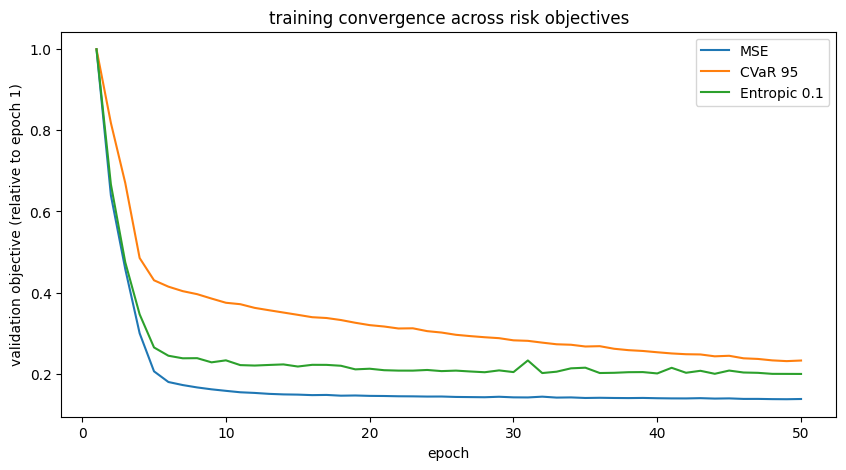

In [19]:
plt.figure(figsize=(10, 5))

for name, history in training_histories.items():
    normalized = history["val_loss"] / history["val_loss"].iloc[0]

    plt.plot(
        history["epoch"],
        normalized,
        label=name
    )

plt.xlabel("epoch")
plt.ylabel("validation objective (relative to epoch 1)")
plt.title("training convergence across risk objectives")

plt.legend()
plt.show()

In [25]:
@torch.no_grad()
def evaluate_policy(model, loader):
    model.eval()

    pnl_batches = []
    cost_batches = []
    share_turnover_batches = []
    notional_turnover_batches = []

    for (spot_paths, variance_paths) in loader:
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = variance_paths.to(device=device, dtype=DTYPE)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=variance_paths,
            K=K,
            T=T,
            premium=heston_premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate
        )

        pnl_batches.append(result["pnl"].cpu())
        cost_batches.append(result["transaction_costs"].cpu())
        share_turnover_batches.append(result["share_turnover"].cpu())
        notional_turnover_batches.append(result["notional_turnover"].cpu())

    return {
        "pnl": torch.cat(pnl_batches).numpy(),
        "transaction_costs": torch.cat(cost_batches).numpy(),
        "share_turnover": torch.cat(share_turnover_batches).numpy(),
        "notional_turnover": torch.cat(notional_turnover_batches).numpy(),
    }


In [26]:
_, _, test_loader = make_loaders()

test_results = {}

for name, model in trained_models.items():
    test_results[name] = evaluate_policy(
        model=model,
        loader=test_loader
    )


In [24]:
def empirical_cvar_loss(pnl, alpha=0.95):
    """
    average loss in the worst (1-alpha) fraction of outcomes
    """
    pnl = np.asarray(pnl)
    losses = -pnl
    n = len(losses)

    tail_count = max(1, int(np.ceil(1.0 - alpha) * n))

    worst_losses = np.partition(losses, n - tail_count)[n - tail_count]

    return worst_losses.mean()

In [27]:
def policy_metrics(result):
    pnl = result["pnl"]

    return {
        "mean_pnl": np.mean(pnl),
        "std_pnl": np.std(pnl, ddof=1),
        "rmse": np.sqrt(np.mean(pnl**2)),
        "q05": np.quantile(pnl, 0.05),
        "q01": np.quantile(pnl, 0.01),
        "cvar95_loss": empirical_cvar_loss(pnl, alpha=0.95),
        "cvar99_loss": empirical_cvar_loss(pnl, alpha=0.99),
        "mean_tc": np.mean(result["transaction_costs"]),
        "mean_turnover": np.mean(result["share_turnover"])
    }

In [29]:
records = []

for name, result in test_results.items():
    records.append({
        "objective": name,
        **policy_metrics(result)
    })

results_df = pd.DataFrame(records).set_index("objective")

results_df

,mean_pnl,std_pnl,rmse,q05,q01,cvar95_loss,cvar99_loss,mean_tc,mean_turnover
objective,,,,,,,,,
MSE,-0.288296,2.001916,2.022548,-3.898982,-5.946207,-5.809238,-5.809238,0.303037,3.008342
CVaR 95,-0.192858,2.105010,2.113805,-3.760089,-6.306574,-6.196259,-6.196259,0.204854,2.052988
Entropic 0.1,-0.148214,2.235163,2.240050,-3.991352,-6.081682,-6.338886,-6.338886,0.160759,1.622264


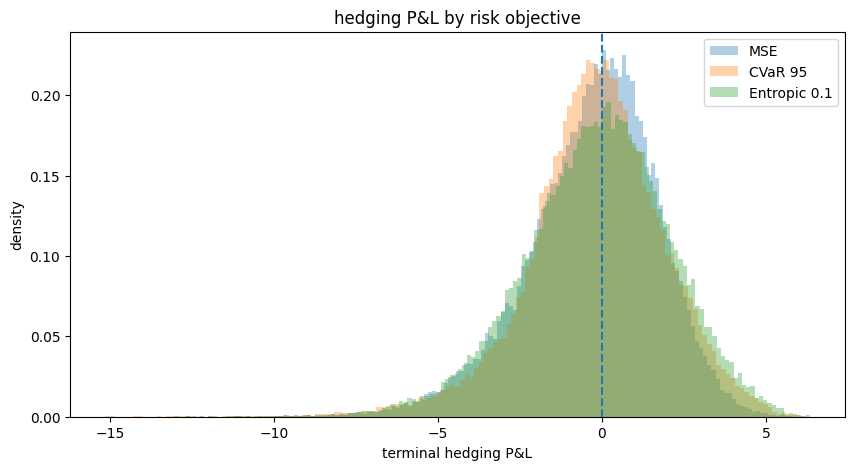

In [41]:
plt.figure(figsize=(10, 5))

for name, result in test_results.items():
    plt.hist(
        result["pnl"],
        bins=150,
        density=True,
        alpha=0.35,
        label=name
    )

plt.axvline(0.0, linestyle="--")

plt.xlabel("terminal hedging P&L")
plt.ylabel("density")
plt.title("hedging P&L by risk objective")

plt.legend()
plt.show()

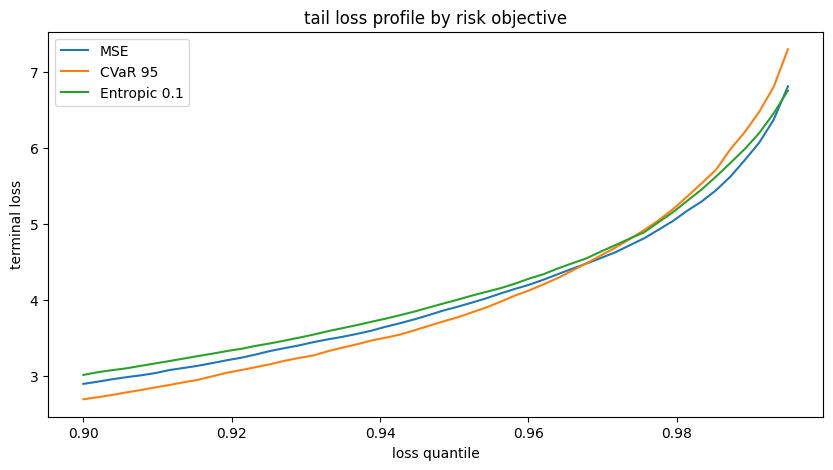

In [42]:
quantile_levels = np.linspace(0.90, 0.995, 50)

plt.figure(figsize=(10, 5))

for name, result in test_results.items():
    losses = -result["pnl"]
    tail_quantiles = np.quantile(losses, quantile_levels)

    plt.plot(quantile_levels, tail_quantiles, label=name)

plt.xlabel("loss quantile")
plt.ylabel("terminal loss")
plt.title("tail loss profile by risk objective")

plt.legend()
plt.show()

In [43]:
inventory_grid = torch.linspace(0.0, 1.0, 300, device=device)

S_eval = 90.0
vol_eval = 0.40
v_eval = vol_eval**2

t_eval = 0.75

In [44]:
def policy_vs_inventory(model):
    with torch.no_grad():
        log_moneyness = torch.full_like(inventory_grid, np.log(S_eval / K))
        variance_feature = torch.full_like(inventory_grid, v_eval / theta)
        tau_feature = torch.full_like(inventory_grid, (T - t_eval) / T)

        state = torch.stack([
            log_moneyness,
            variance_feature,
            tau_feature,
            inventory_grid
        ], dim=1)

        target = model(state)

    return target.cpu().numpy()


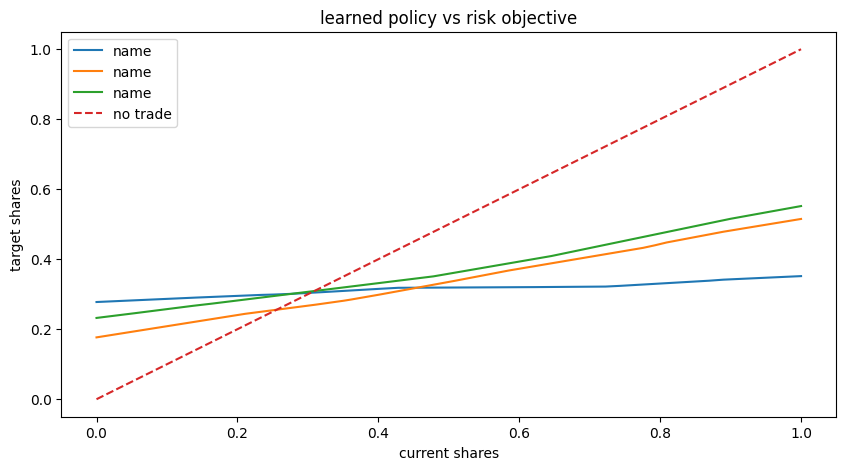

In [46]:
inventory_np = inventory_grid.cpu().numpy()

plt.figure(figsize=(10, 5))

for name, model in trained_models.items():
    target = policy_vs_inventory(model)

    plt.plot(
        inventory_np,
        target,
        label="name"
    )

plt.plot(
    inventory_np,
    inventory_np,
    linestyle="--",
    label="no trade"
)

plt.xlabel("current shares")
plt.ylabel("target shares")
plt.title("learned policy vs risk objective")

plt.legend()
plt.show()


In [48]:
log_returns = np.diff(np.log(test_sim_np.spot), axis=1)
realized_variance = np.sum(log_returns**2, axis=1)
realized_volatility = np.sqrt(realized_variance)

vol_bucket = pd.qcut(
    realized_volatility,
    q=5,
    labels=[
        "lowest",
        "low",
        "medium",
        "high",
        "highest"
    ]
)

bucket_results = []

for bucket in pd.unique(vol_bucket):
    mask = vol_bucket == bucket

    for name, result in test_results.items():
        pnl = result["pnl"][mask]

        bucket_results.append({
            "vol_bucket": bucket,
            "objective": name,
            "cvar95_loss": empirical_cvar_loss(pnl, alpha=0.95)
        })

bucket_results = pd.DataFrame(bucket_results)
bucket_results.pivot(
    index="vol_bucket",
    columns="objective",
    values="cvar95_loss",
)

objective,CVaR 95,Entropic 0.1,MSE
vol_bucket,,,
high,-2.991853,-3.980640,-3.272671
highest,-1.979041,-3.858855,-2.561481
low,-5.210911,-5.897694,-5.095497
lowest,-6.196259,-6.338886,-5.809238
medium,-4.025585,-4.756577,-3.674816
